In [ ]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [ ]:
df1 = pd.read_csv('banglore.csv')
df2 = pd.read_csv('Bengaluru_House_Data.csv')

combined_df = pd.concat([df1, df2], ignore_index=True)
# ignore_index=True makes sure the row numbers (0, 1, 2...) stay in order

In [ ]:
combined_df.drop_duplicates(inplace = True)

In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
combined_df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00


In [ ]:
X = combined_df[['area_type', 'size', 'location', 'society', 'total_sqft']].copy()
y = combined_df['price']

In [ ]:
# Convert size
X['size'] = X['size'].str.extract('(\d+)').astype(float)

# Convert sqft
X['total_sqft'] = X['total_sqft'].apply(convert_sqft_to_num)
X['total_sqft'] = X['total_sqft'].fillna(X['total_sqft'].median())

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5840/2162568359.py:2: SyntaxWarning: invalid escape sequence '\d'
  X['size'] = X['size'].str.extract('(\d+)').astype(float)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_5840/2162568359.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['total_sqft'] = X['total_sqft'].fillna(X['total_sqft'].median())


In [ ]:
# Define columns
categorical_cols = ['area_type', 'location', 'society']
numeric_cols = ['size', 'total_sqft']

In [ ]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [ ]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
lgb = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 321
[LightGBM] [Info] Number of data points in the train set: 10232, number of used features: 154
[LightGBM] [Info] Start training from score 114.296633


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, verbose=0)
cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

In [ ]:
def evaluate(name, y_test, y_pred):
    print(f"{name}")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MSE:", mean_absolute_error(y_test, y_pred))
    print("-----------")

evaluate("XGBoost", y_test, y_pred_xgb)
evaluate("LightGBM", y_test, y_pred_lgb)
evaluate("CatBoost", y_test, y_pred_cat)

XGBoost
R2 Score: 0.39721652746557545
MSE: 13536.416696050566
MSE: 49.64051266496188
-----------
LightGBM
R2 Score: 0.3394570074846831
MSE: 14833.494280706085
MSE: 51.53466995614005
-----------
CatBoost
R2 Score: 0.3788808571742657
MSE: 13948.17196933469
MSE: 52.72415390258645
-----------


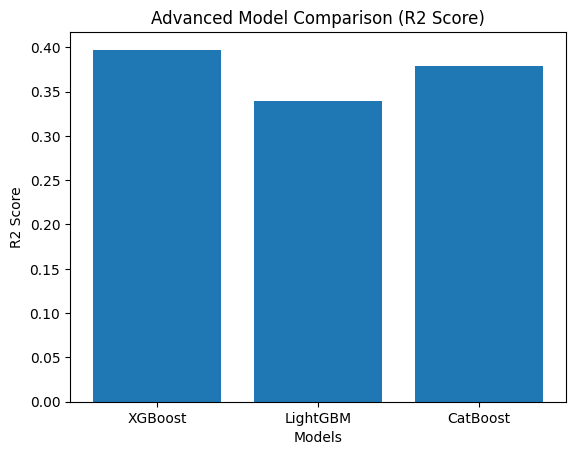

In [ ]:
models = ['XGBoost', 'LightGBM', 'CatBoost']
scores = [
    r2_score(y_test, y_pred_xgb),
    r2_score(y_test, y_pred_lgb),
    r2_score(y_test, y_pred_cat)
]

plt.bar(models, scores)
plt.title("Advanced Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

In [1]:
# Clone repository
!git clone https://github.com/Suhasdk22/house-price-predicition.git

# Move into repo
%cd house-price-predicition

Cloning into 'house-price-predicition'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 9 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.
/content/house-price-predicition


In [2]:
# Move into repo
%cd house-price-predicition


[Errno 2] No such file or directory: 'house-price-predicition'
/content/house-price-predicition
